# 📄 Resume / Candidate Screening System
## Machine Learning Internship — Future Interns | Task 3
**Intern:** Panashe Sofa | **CIN:** FIT/FEB26/ML5773 | **Track:** Machine Learning

---
### 📌 Project Overview
This ML system automatically screens, scores, and ranks resumes
against a job description — helping recruiters shortlist candidates
faster, identify skill gaps, and make data-driven hiring decisions.

### 🎯 Objectives
- Clean and preprocess resume text using NLP
- Extract skills and keywords from resumes
- Score resumes against a job description using TF-IDF similarity
- Rank candidates by role fit score
- Identify missing skills per candidate
- Classify resumes by job category

In [1]:
# ============================================================
# CELL 2: Install & Import All Libraries
# ============================================================
import subprocess, sys

for pkg in ['nltk','scikit-learn','pandas','numpy',
            'matplotlib','seaborn','wordcloud']:
    subprocess.check_call([sys.executable, '-m', 'pip',
                           'install', pkg, '--quiet'])

import pandas as pd
import numpy as np
import re, string, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

import nltk
for item in ['stopwords','punkt','wordnet',
             'punkt_tab','omw-1.4']:
    nltk.download(item, quiet=True)

from nltk.corpus   import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem     import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise  import cosine_similarity
from sklearn.model_selection   import train_test_split
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.naive_bayes       import MultinomialNB
from sklearn.metrics           import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    confusion_matrix, classification_report)
from sklearn.preprocessing     import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
print("✅ All libraries ready!")

✅ All libraries ready!


In [3]:
# ============================================================
# CELL 3: Load Dataset & Explore
# ============================================================

df = pd.read_csv('data/resume.csv')

print("=" * 60)
print("📦 RESUME DATASET OVERVIEW")
print("=" * 60)
print(f"Total Resumes   : {len(df):,}")
print(f"Columns         : {df.columns.tolist()}")
print(f"\nJob Categories  : {df['Category'].nunique()}")
print(f"\nResumes per Category:")
print(df['Category'].value_counts().to_string())
print(f"\nSample Resume (first 300 chars):")
print(df['Resume_str'].iloc[0][:300])
df.head(3)

📦 RESUME DATASET OVERVIEW
Total Resumes   : 2,484
Columns         : ['ID', 'Resume_str', 'Resume_html', 'Category']

Job Categories  : 24

Resumes per Category:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22

Sample Resume (first 300 chars):
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summar

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
# ============================================================
# CELL 4: Text Cleaning & Preprocessing
# ============================================================

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_resume(text):
    if not isinstance(text, str):
        return ""
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    # Remove phone numbers
    text = re.sub(r'\+?\d[\d\s\-]{8,}\d', ' ', text)
    # Remove special characters keeping letters/spaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Lowercase
    text = text.lower()
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenize + remove stopwords + lemmatize
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words
              and len(w) > 2
              and w.isalpha()]
    return ' '.join(tokens)

print("🔄 Cleaning resumes... (may take 1-2 minutes)")
df['clean_resume'] = df['Resume_str'].apply(clean_resume)
df['word_count']   = df['clean_resume'].apply(
    lambda x: len(x.split()))
df = df[df['clean_resume'].str.strip() != ''
       ].reset_index(drop=True)

print(f"✅ Cleaned {len(df):,} resumes")
print(f"\nAvg word count : {df['word_count'].mean():.0f} words")
print(f"Min word count : {df['word_count'].min()} words")
print(f"Max word count : {df['word_count'].max()} words")
print(f"\nSample cleaned:")
print(df['clean_resume'].iloc[0][:200])

🔄 Cleaning resumes... (may take 1-2 minutes)
✅ Cleaned 2,483 resumes

Avg word count : 584 words
Min word count : 74 words
Max word count : 3543 words

Sample cleaned:
administrator marketing associate administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customer focused team strive


In [5]:
# ============================================================
# CELL 5: Define Job Descriptions for Screening
# ============================================================

# These are realistic job descriptions for 5 common roles
# The system will score ALL resumes against EACH job

job_descriptions = {
    'Data Scientist': """
        We are looking for a Data Scientist with strong experience
        in Python, machine learning, deep learning, and data analysis.
        Required skills: Python, R, SQL, TensorFlow, PyTorch, scikit-learn,
        pandas, numpy, statistics, data visualization, matplotlib, seaborn,
        Jupyter, regression, classification, clustering, NLP, neural networks,
        feature engineering, model evaluation, A/B testing, big data, Spark,
        Tableau, Power BI, data mining, predictive modeling, computer vision.
    """,

    'Java Developer': """
        Looking for an experienced Java Developer to build enterprise
        applications. Required: Java, Spring Boot, Hibernate, microservices,
        REST API, Maven, Git, SQL, MySQL, PostgreSQL, JUnit, Docker,
        Kubernetes, AWS, Linux, object oriented programming, design patterns,
        multithreading, Spring MVC, Angular, React, JavaScript, HTML, CSS,
        Agile, Scrum, CI/CD, Jenkins, software development lifecycle.
    """,

    'HR Manager': """
        Seeking an HR Manager experienced in talent acquisition, employee
        relations, and HR operations. Skills: recruitment, hiring, onboarding,
        payroll, performance management, training, development, HRIS systems,
        labor law, compliance, compensation, benefits, employee engagement,
        organizational development, succession planning, HR policies,
        conflict resolution, diversity inclusion, SAP HR, Workday, PeopleSoft.
    """,

    'Web Designer': """
        We need a creative Web Designer with front-end development skills.
        Required: HTML, CSS, JavaScript, React, Angular, Vue, Bootstrap,
        Figma, Adobe XD, Photoshop, Illustrator, UI UX design, responsive
        design, wireframing, prototyping, WordPress, Shopify, SEO,
        web accessibility, cross browser testing, Git, graphic design,
        typography, color theory, user experience, user interface.
    """,

    'DevOps Engineer': """
        Looking for a DevOps Engineer to manage cloud infrastructure and
        CI/CD pipelines. Required: Docker, Kubernetes, AWS, Azure, GCP,
        Jenkins, Git, Linux, bash scripting, Terraform, Ansible, monitoring,
        Prometheus, Grafana, CI/CD, microservices, cloud architecture,
        networking, security, Python, automation, Agile, containers,
        infrastructure as code, site reliability, load balancing, scalability.
    """
}

print("=" * 60)
print("📋 JOB DESCRIPTIONS DEFINED")
print("=" * 60)
for role, desc in job_descriptions.items():
    word_count = len(desc.split())
    print(f"  ✅ {role:<25} ({word_count} words)")

print(f"\nTotal roles defined: {len(job_descriptions)}")

📋 JOB DESCRIPTIONS DEFINED
  ✅ Data Scientist            (59 words)
  ✅ Java Developer            (48 words)
  ✅ HR Manager                (45 words)
  ✅ Web Designer              (48 words)
  ✅ DevOps Engineer           (46 words)

Total roles defined: 5


In [7]:
# ============================================================
# CELL 6: Skill Extraction using NLP
# ============================================================

# Comprehensive technical skills dictionary
SKILLS_DB = {
    # Programming Languages
    'python', 'java', 'javascript', 'sql', 'r', 'scala',
    'golang', 'ruby', 'php', 'swift', 'kotlin', 'rust', 'perl',
    'matlab', 'typescript', 'bash', 'powershell',

    # ML & Data Science
    'tensorflow', 'pytorch', 'keras', 'scikit', 'sklearn',
    'pandas', 'numpy', 'scipy', 'matplotlib', 'seaborn',
    'machine learning', 'deep learning', 'nlp', 'computer vision',
    'neural network', 'regression', 'classification', 'clustering',
    'random forest', 'xgboost', 'lstm', 'transformer', 'bert',
    'statistics', 'modeling', 'prediction', 'analytics',

    # Web & Frontend
    'html', 'css', 'react', 'angular', 'vue', 'bootstrap',
    'jquery', 'nodejs', 'django', 'flask', 'spring', 'wordpress',
    'figma', 'photoshop', 'illustrator', 'sketch',

    # DevOps & Cloud
    'docker', 'kubernetes', 'aws', 'azure', 'gcp', 'jenkins',
    'git', 'linux', 'terraform', 'ansible', 'ci/cd', 'devops',
    'microservices', 'api', 'rest',

    # Databases
    'mysql', 'postgresql', 'mongodb', 'oracle', 'redis',
    'cassandra', 'sqlite', 'database', 'hadoop', 'spark',

    # Business & HR
    'recruitment', 'hiring', 'payroll', 'training', 'compliance',
    'management', 'leadership', 'communication', 'teamwork',
    'agile', 'scrum', 'project management', 'excel', 'tableau',
}

def extract_skills(text):
    """Extract skills from resume text"""
    text_lower = text.lower()
    found = []
    for skill in SKILLS_DB:
        if skill in text_lower:
            found.append(skill)
    return found

# Extract skills from all resumes
print("🔍 Extracting skills from resumes...")
df['skills'] = df['clean_resume'].apply(extract_skills)
df['skill_count'] = df['skills'].apply(len)

print(f"✅ Skills extracted from {len(df):,} resumes")
print(f"\nAvg skills per resume : {df['skill_count'].mean():.1f}")
print(f"Max skills in resume  : {df['skill_count'].max()}")
print(f"Min skills in resume  : {df['skill_count'].min()}")

print(f"\nSample — {df['Category'].iloc[0]} resume skills:")
print(f"  {df['skills'].iloc[0][:15]}")

# Most common skills across all resumes
all_skills = [s for skills in df['skills'] for s in skills]
top_skills = Counter(all_skills).most_common(20)
print(f"\n🏆 Top 20 Most Common Skills:")
for skill, count in top_skills:
    bar = '█' * (count // 30)
    print(f"  {skill:<25} {count:>4}  {bar}")

🔍 Extracting skills from resumes...
✅ Skills extracted from 2,483 resumes

Avg skills per resume : 7.4
Max skills in resume  : 36
Min skills in resume  : 1

Sample — HR resume skills:
  ['training', 'swift', 'leadership', 'r', 'payroll', 'management']

🏆 Top 20 Most Common Skills:
  r                         2483  ██████████████████████████████████████████████████████████████████████████████████
  management                2120  ██████████████████████████████████████████████████████████████████████
  training                  1736  █████████████████████████████████████████████████████████
  excel                     1616  █████████████████████████████████████████████████████
  communication             1505  ██████████████████████████████████████████████████
  leadership                1028  ██████████████████████████████████
  rest                       937  ███████████████████████████████
  compliance                 777  █████████████████████████
  database                   677  ██

In [8]:
# ============================================================
# CELL 7: Resume Scoring & Ranking Engine
# ============================================================

def score_resumes(job_title, job_description, top_n=10):
    """
    Score all resumes against a job description using
    TF-IDF cosine similarity.
    Returns ranked dataframe of top candidates.
    """
    # Clean the job description
    clean_jd = clean_resume(job_description)

    # Build TF-IDF vectorizer on ALL resumes + job description
    all_texts = df['clean_resume'].tolist() + [clean_jd]
    tfidf     = TfidfVectorizer(
        max_features = 10000,
        ngram_range  = (1, 2),
        min_df       = 1,
        sublinear_tf = True
    )
    tfidf_matrix = tfidf.fit_transform(all_texts)

    # Job description is the last row
    jd_vector      = tfidf_matrix[-1]
    resume_vectors = tfidf_matrix[:-1]

    # Cosine similarity: how similar is each resume to the JD?
    similarity_scores = cosine_similarity(
        resume_vectors, jd_vector).flatten()

    # Add scores to dataframe
    result_df = df[['Category','Resume_str',
                    'clean_resume','skills',
                    'skill_count']].copy()
    result_df['similarity_score'] = similarity_scores
    result_df['match_percent']    = (
        similarity_scores * 100).round(2)

    # Extract JD skills for gap analysis
    jd_skills = set(extract_skills(clean_jd))

    # Identify matched and missing skills per candidate
    result_df['matched_skills'] = result_df['skills'].apply(
        lambda s: list(set(s) & jd_skills))
    result_df['missing_skills'] = result_df['skills'].apply(
        lambda s: list(jd_skills - set(s)))
    result_df['match_skill_count'] = result_df[
        'matched_skills'].apply(len)

    # Final score: blend similarity (70%) + skill match (30%)
    max_skills = len(jd_skills) if jd_skills else 1
    result_df['skill_score'] = (
        result_df['match_skill_count'] / max_skills)
    result_df['final_score'] = (
        0.70 * result_df['similarity_score'] +
        0.30 * result_df['skill_score']
    )
    result_df['final_percent'] = (
        result_df['final_score'] * 100).round(2)

    # Rank candidates
    result_df = result_df.sort_values(
        'final_score', ascending=False
    ).reset_index(drop=True)
    result_df['rank'] = result_df.index + 1

    return result_df.head(top_n), jd_skills

print("=" * 60)
print("🎯 SCORING RESUMES FOR: Data Scientist")
print("=" * 60)

top_candidates, jd_skills = score_resumes(
    'Data Scientist',
    job_descriptions['Data Scientist'],
    top_n=10
)

print(f"\nJD Skills identified: {len(jd_skills)}")
print(f"JD Skills: {sorted(jd_skills)[:10]}...")

print(f"\n🏆 TOP 10 CANDIDATES FOR DATA SCIENTIST ROLE:")
print(f"{'Rank':<5} {'Category':<25} {'Score':>8} {'Match%':>8} "
      f"{'Skills Matched':>15}")
print("─" * 70)
for _, row in top_candidates.iterrows():
    print(f"#{row['rank']:<4} {row['Category']:<25} "
          f"{row['final_score']:.4f}  "
          f"{row['final_percent']:>6.1f}%  "
          f"{row['match_skill_count']:>8} skills")

🎯 SCORING RESUMES FOR: Data Scientist

JD Skills identified: 20
JD Skills: ['classification', 'clustering', 'computer vision', 'deep learning', 'machine learning', 'matplotlib', 'modeling', 'neural network', 'nlp', 'numpy']...

🏆 TOP 10 CANDIDATES FOR DATA SCIENTIST ROLE:
Rank  Category                     Score   Match%  Skills Matched
──────────────────────────────────────────────────────────────────────
#1    AUTOMOBILE                0.3723    37.2%        11 skills
#2    ENGINEERING               0.3426    34.3%         8 skills
#3    CONSULTANT                0.3101    31.0%         7 skills
#4    AUTOMOBILE                0.2736    27.4%         9 skills
#5    ENGINEERING               0.2422    24.2%        10 skills
#6    DIGITAL-MEDIA             0.2345    23.4%         6 skills
#7    BANKING                   0.2156    21.6%         6 skills
#8    AGRICULTURE               0.2135    21.4%         6 skills
#9    ENGINEERING               0.1884    18.8%         7 skills
#10  

In [9]:
# ============================================================
# CELL 8: Score All Job Roles & Store Results
# ============================================================

all_results = {}
all_jd_skills = {}

print("=" * 60)
print("🚀 SCREENING RESUMES FOR ALL 5 ROLES")
print("=" * 60)

for role, jd in job_descriptions.items():
    results, jd_skills = score_resumes(role, jd, top_n=10)
    all_results[role]   = results
    all_jd_skills[role] = jd_skills

    top1 = results.iloc[0]
    avg  = results['final_percent'].mean()

    print(f"\n📌 {role}")
    print(f"   Top Candidate : {top1['Category']} "
          f"({top1['final_percent']:.1f}% match)")
    print(f"   Avg Top-10 Score : {avg:.1f}%")
    print(f"   JD Skills Count  : {len(jd_skills)}")

print("\n✅ All roles screened successfully!")

🚀 SCREENING RESUMES FOR ALL 5 ROLES

📌 Data Scientist
   Top Candidate : AUTOMOBILE (37.2% match)
   Avg Top-10 Score : 25.8%
   JD Skills Count  : 20

📌 Java Developer
   Top Candidate : INFORMATION-TECHNOLOGY (53.7% match)
   Avg Top-10 Score : 35.1%
   JD Skills Count  : 21

📌 HR Manager
   Top Candidate : HR (47.5% match)
   Avg Top-10 Score : 44.3%
   JD Skills Count  : 7

📌 Web Designer
   Top Candidate : DIGITAL-MEDIA (32.1% match)
   Avg Top-10 Score : 28.8%
   JD Skills Count  : 13

📌 DevOps Engineer
   Top Candidate : BANKING (29.0% match)
   Avg Top-10 Score : 20.6%
   JD Skills Count  : 17

✅ All roles screened successfully!


In [10]:
# ============================================================
# CELL 9: Detailed Candidate Report (Data Scientist Role)
# ============================================================

role     = 'Data Scientist'
results  = all_results[role]
jd_skills = all_jd_skills[role]

print("=" * 60)
print(f"📋 DETAILED CANDIDATE REPORT — {role}")
print("=" * 60)

for _, row in results.head(5).iterrows():
    print(f"\n{'='*55}")
    print(f"  🏆 RANK #{row['rank']}  |  Category: {row['Category']}")
    print(f"  📊 Final Score    : {row['final_percent']:.1f}%")
    print(f"  🎯 TF-IDF Match   : {row['match_percent']:.1f}%")
    print(f"  🔧 Skills Matched : {row['match_skill_count']} skills")
    print(f"  ✅ Matched: {', '.join(row['matched_skills'][:8])}")
    if row['missing_skills']:
        print(f"  ❌ Missing: "
              f"{', '.join(list(row['missing_skills'])[:8])}")
    else:
        print(f"  ✅ No major skill gaps!")
    print(f"  📝 Resume Preview:")
    print(f"     {row['Resume_str'][:150].strip()}...")

📋 DETAILED CANDIDATE REPORT — Data Scientist

  🏆 RANK #1  |  Category: AUTOMOBILE
  📊 Final Score    : 37.2%
  🎯 TF-IDF Match   : 29.6%
  🔧 Skills Matched : 11 skills
  ✅ Matched: regression, spark, r, python, modeling, classification, sql, numpy
  ❌ Missing: seaborn, nlp, computer vision, clustering, deep learning, neural network, machine learning, pytorch
  📝 Resume Preview:
     DATA ANALYST       Professional Summary    Industrial and Systems Engineering graduate, certified Base SAS Programmer and a Lean Six Sigma Gr...

  🏆 RANK #2  |  Category: ENGINEERING
  📊 Final Score    : 34.3%
  🎯 TF-IDF Match   : 31.8%
  🔧 Skills Matched : 8 skills
  ✅ Matched: regression, r, python, modeling, sql, machine learning, tableau, clustering
  ❌ Missing: seaborn, nlp, spark, scikit, computer vision, classification, deep learning, neural network
  📝 Resume Preview:
     ENGINEERING AND QUALITY TECHNICIAN       Career Overview    A highly experienced skilled graduate with Analytics degree with a 

In [12]:
# ============================================================
# CELL 10: Train Resume Category Classifier
# ============================================================

# Encode labels
le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['Category'])

# TF-IDF features
tfidf_clf = TfidfVectorizer(
    max_features = 10000,
    ngram_range  = (1, 2),
    sublinear_tf = True,
    min_df       = 2
)
X = tfidf_clf.fit_transform(df['clean_resume'])
y = df['category_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]:,}  |  "
      f"Test: {X_test.shape[0]:,}")

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=5, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42),
    'Naive Bayes': MultinomialNB(alpha=0.1)
}

clf_results = {}
print("\n" + "=" * 60)
print("🤖 RESUME CATEGORY CLASSIFICATION RESULTS")
print("=" * 60)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred,
               average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred,
               average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred,
               average='weighted', zero_division=0)

    clf_results[name] = {
        'model': model, 'predictions': y_pred,
        'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1
    }
    print(f"\n📌 {name}")
    print(f"   Accuracy  : {acc:.4f}")
    print(f"   Precision : {prec:.4f}")
    print(f"   Recall    : {rec:.4f}")
    print(f"   F1 Score  : {f1:.4f}")

best_clf_name  = max(clf_results,
                     key=lambda k: clf_results[k]['F1'])
best_clf_model = clf_results[best_clf_name]['model']
best_preds     = clf_results[best_clf_name]['predictions']

print(f"\n🏆 Best Classifier: {best_clf_name} "
      f"(F1={clf_results[best_clf_name]['F1']:.4f})")

Train: 1,986  |  Test: 497

🤖 RESUME CATEGORY CLASSIFICATION RESULTS

📌 Logistic Regression
   Accuracy  : 0.6841
   Precision : 0.6935
   Recall    : 0.6841
   F1 Score  : 0.6722

📌 Random Forest
   Accuracy  : 0.7445
   Precision : 0.7570
   Recall    : 0.7445
   F1 Score  : 0.7257

📌 Naive Bayes
   Accuracy  : 0.5815
   Precision : 0.5909
   Recall    : 0.5815
   F1 Score  : 0.5575

🏆 Best Classifier: Random Forest (F1=0.7257)


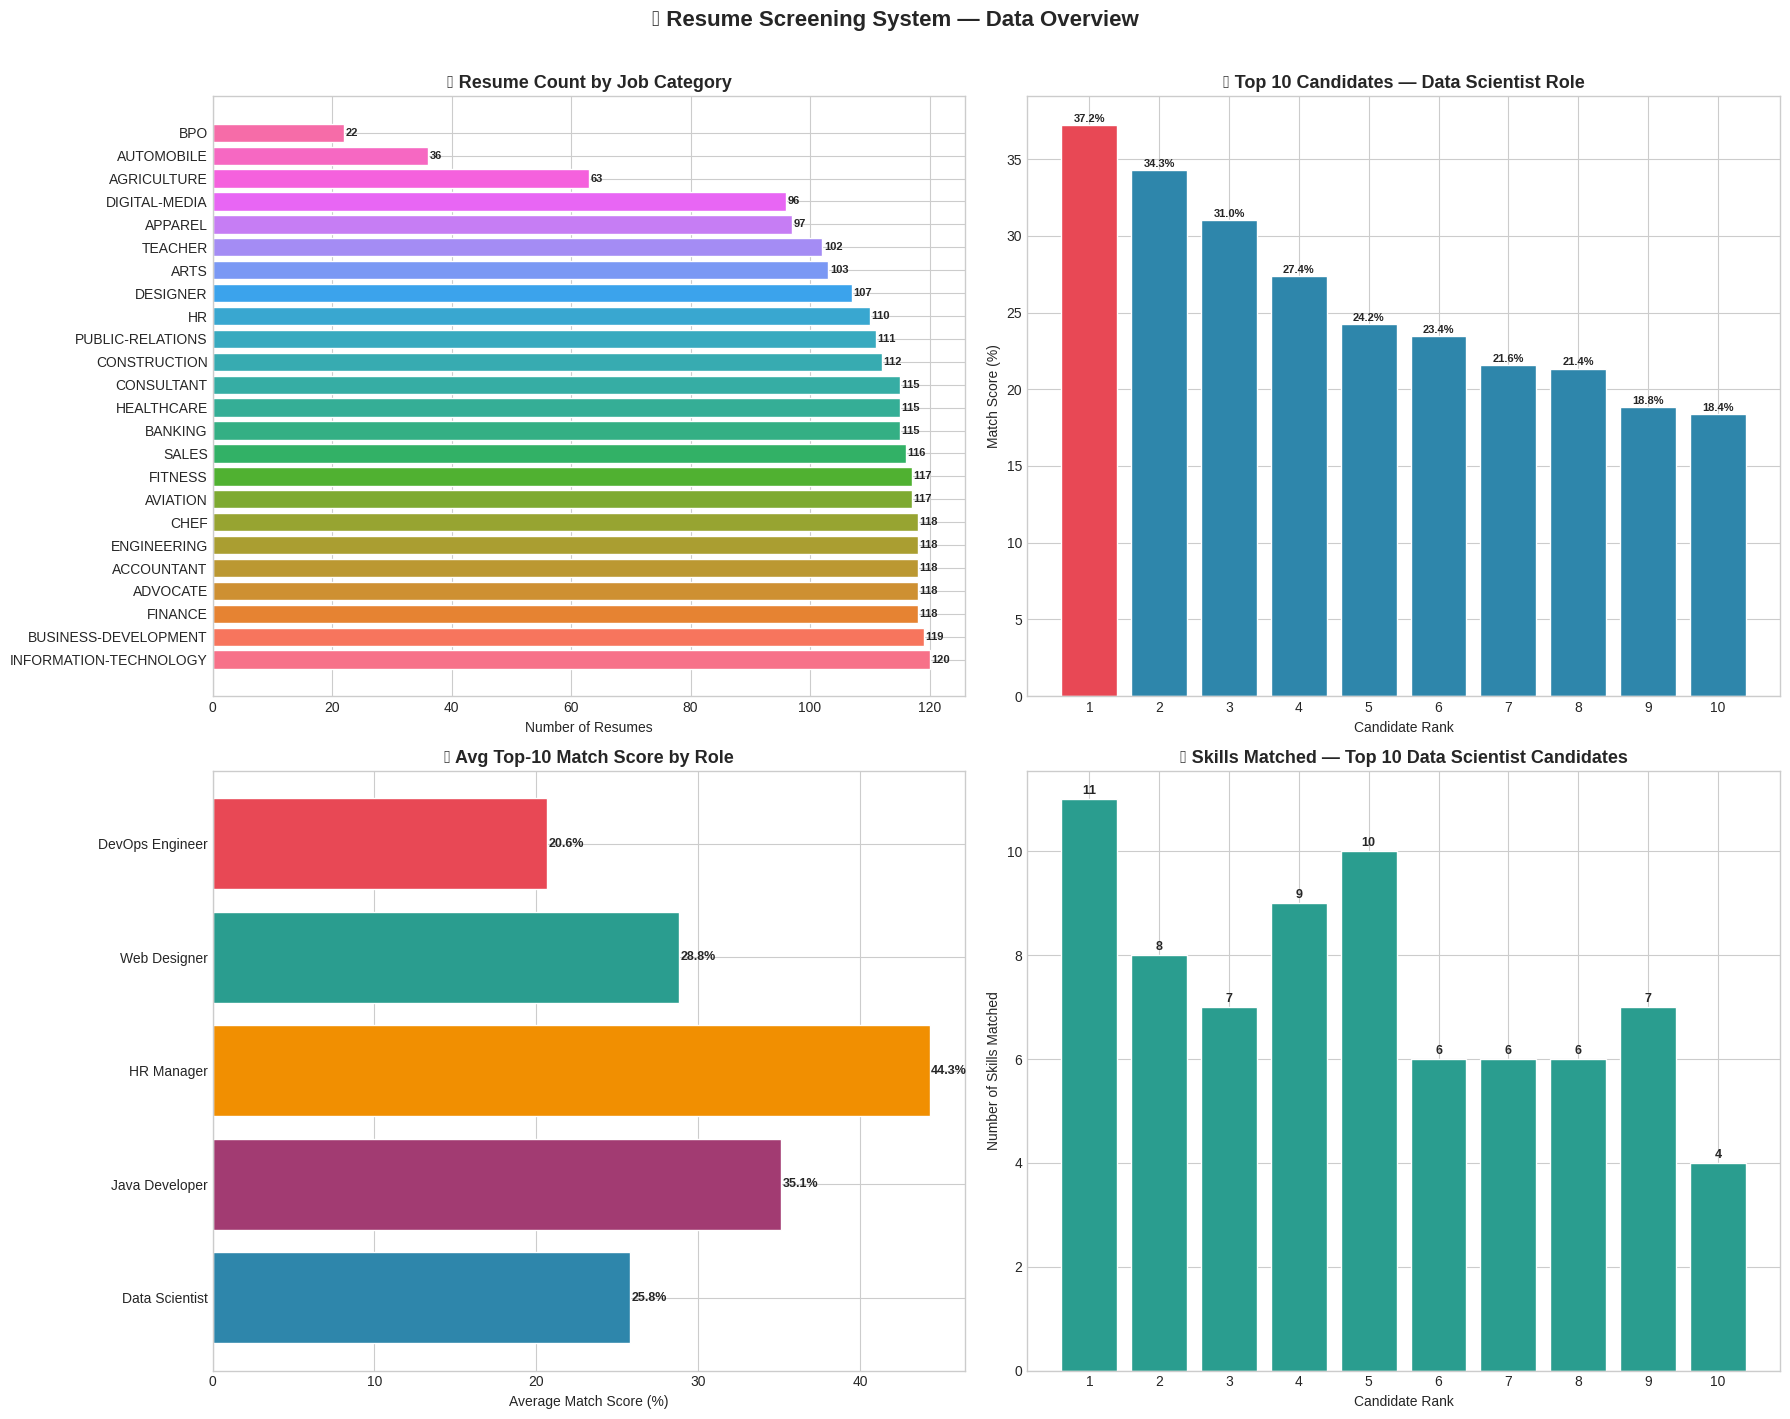

✅ Saved: resume_overview.png


In [13]:
# ============================================================
# CELL 11: Data Exploration Visualizations
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ── Plot 1: Resume count by category ───────────────────────
cat_counts = df['Category'].value_counts()
colors1 = sns.color_palette("husl", len(cat_counts))
bars = axes[0,0].barh(
    cat_counts.index, cat_counts.values,
    color=colors1, edgecolor='white')
axes[0,0].set_title('📄 Resume Count by Job Category',
                    fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Number of Resumes')
for bar in bars:
    axes[0,0].text(
        bar.get_width()+0.3,
        bar.get_y()+bar.get_height()/2,
        f'{int(bar.get_width())}',
        va='center', fontsize=8, fontweight='bold')
axes[0,0].set_facecolor('#FFFFFF')

# ── Plot 2: Score distribution for Data Scientist ──────────
ds_scores = all_results['Data Scientist']['final_percent']
axes[0,1].bar(
    range(1, len(ds_scores)+1), ds_scores,
    color=['#E84855' if i == 0 else '#2E86AB'
           for i in range(len(ds_scores))],
    edgecolor='white')
axes[0,1].set_title(
    '🏆 Top 10 Candidates — Data Scientist Role',
    fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Candidate Rank')
axes[0,1].set_ylabel('Match Score (%)')
axes[0,1].set_xticks(range(1, len(ds_scores)+1))
for i, v in enumerate(ds_scores):
    axes[0,1].text(i+1, v+0.2, f'{v:.1f}%',
                   ha='center', fontsize=8,
                   fontweight='bold')
axes[0,1].set_facecolor('#FFFFFF')

# ── Plot 3: Avg top score by role ───────────────────────────
role_scores = {
    role: all_results[role]['final_percent'].mean()
    for role in job_descriptions
}
axes[1,0].barh(
    list(role_scores.keys()),
    list(role_scores.values()),
    color=['#2E86AB','#A23B72','#F18F01',
           '#2A9D8F','#E84855'],
    edgecolor='white')
axes[1,0].set_title(
    '📊 Avg Top-10 Match Score by Role',
    fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Average Match Score (%)')
for i, (role, score) in enumerate(role_scores.items()):
    axes[1,0].text(score+0.1, i,
                   f'{score:.1f}%',
                   va='center', fontsize=9,
                   fontweight='bold')
axes[1,0].set_facecolor('#FFFFFF')

# ── Plot 4: Skills match count — top 10 Data Scientists ────
ds_res = all_results['Data Scientist']
axes[1,1].bar(
    range(1, 11),
    ds_res['match_skill_count'],
    color='#2A9D8F', edgecolor='white')
axes[1,1].set_title(
    '🔧 Skills Matched — Top 10 Data Scientist Candidates',
    fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Candidate Rank')
axes[1,1].set_ylabel('Number of Skills Matched')
axes[1,1].set_xticks(range(1, 11))
for i, v in enumerate(ds_res['match_skill_count']):
    axes[1,1].text(i+1, v+0.1, str(v),
                   ha='center', fontsize=9,
                   fontweight='bold')
axes[1,1].set_facecolor('#FFFFFF')

plt.suptitle('📊 Resume Screening System — Data Overview',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('resume_overview.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Saved: resume_overview.png")

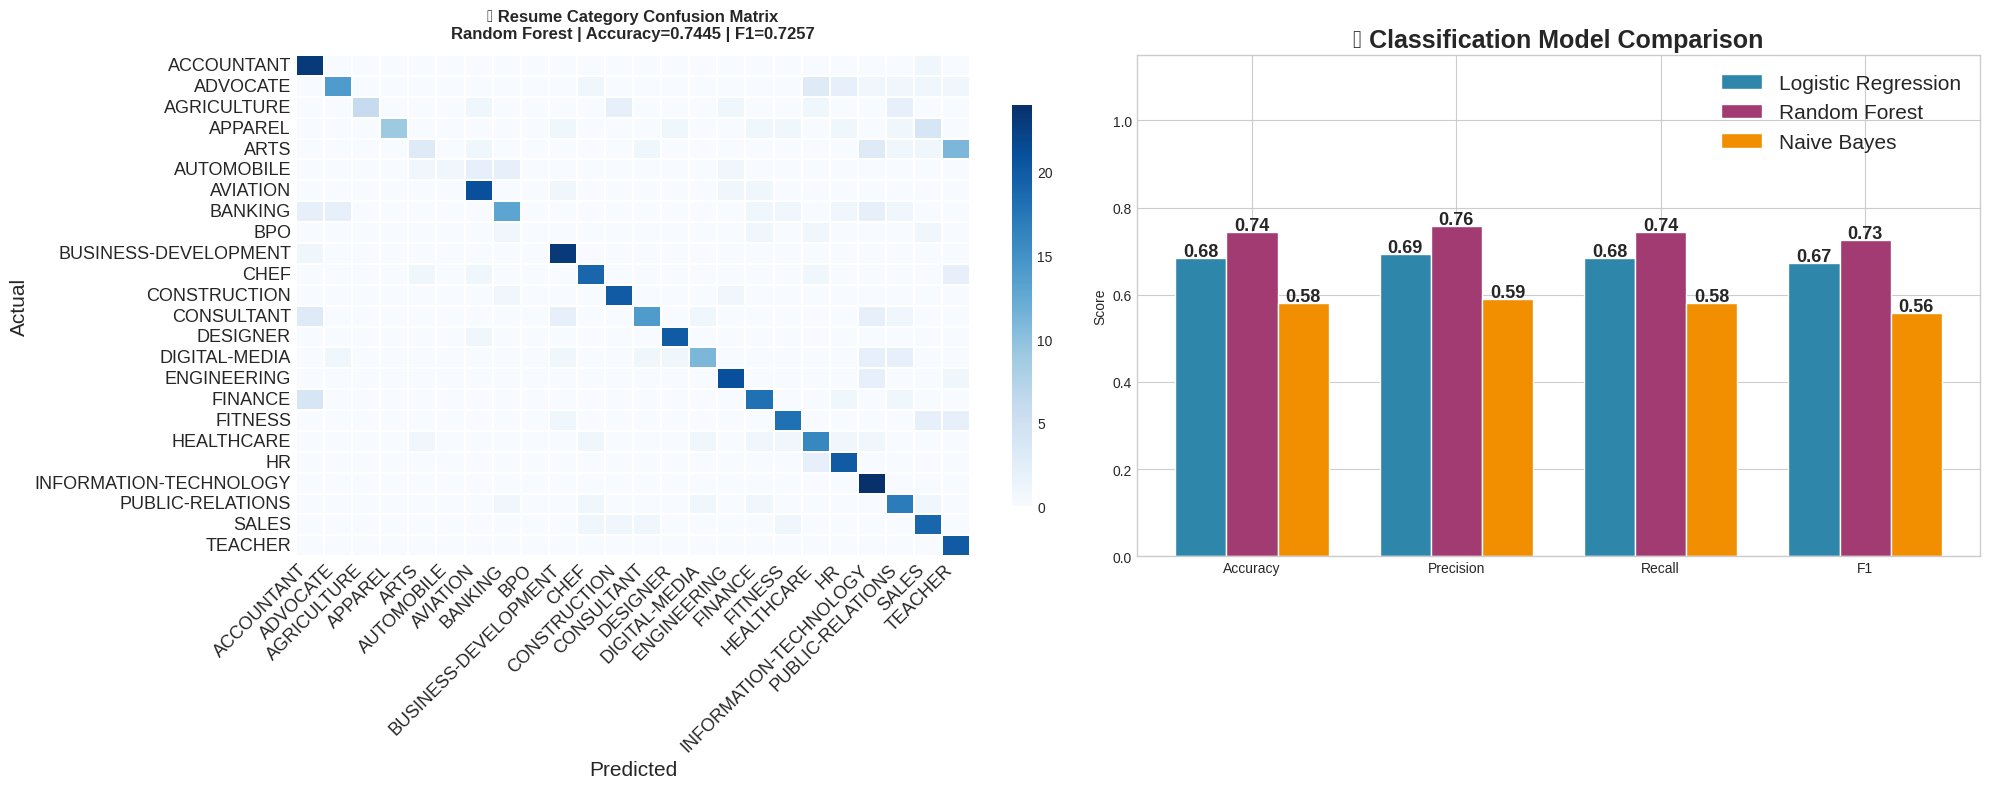

✅ Saved: classification_results.png


In [21]:
# ============================================================
# CELL 12: Classification Charts
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Confusion matrix
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            linewidths=0.3, linecolor='white',
            ax=axes[0], cbar_kws={'shrink':0.8})
axes[0].set_title(
    f'🎯 Resume Category Confusion Matrix\n'
    f'{best_clf_name} | '
    f'Accuracy={clf_results[best_clf_name]["Accuracy"]:.4f} | '
    f'F1={clf_results[best_clf_name]["F1"]:.4f}',
    fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Predicted', fontsize=15)
axes[0].set_ylabel('Actual',    fontsize=15)
plt.setp(axes[0].get_xticklabels(),
         rotation=45, ha='right', fontsize=13)
plt.setp(axes[0].get_yticklabels(),
         rotation=0, fontsize=13)

# Model comparison
model_names = list(clf_results.keys())
metrics     = ['Accuracy','Precision','Recall','F1']
x = np.arange(len(metrics))
w = 0.25
colors = ['#2E86AB','#A23B72','#F18F01']

for i, (name, col) in enumerate(
        zip(model_names, colors)):
    vals = [clf_results[name][m] for m in metrics]
    bars = axes[1].bar(x+i*w, vals, w,
                       label=name, color=col,
                       edgecolor='white')
    for bar, v in zip(bars, vals):
        axes[1].text(
            bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.005,
            f'{v:.2f}', ha='center',
            fontsize=13, fontweight='bold')

axes[1].set_title(
    '🤖 Classification Model Comparison',
    fontsize=18, fontweight='bold')
axes[1].set_xticks(x+w)
axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=15)
axes[1].set_facecolor('#FFFFFF')

plt.tight_layout()
plt.savefig('classification_results.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Saved: classification_results.png")

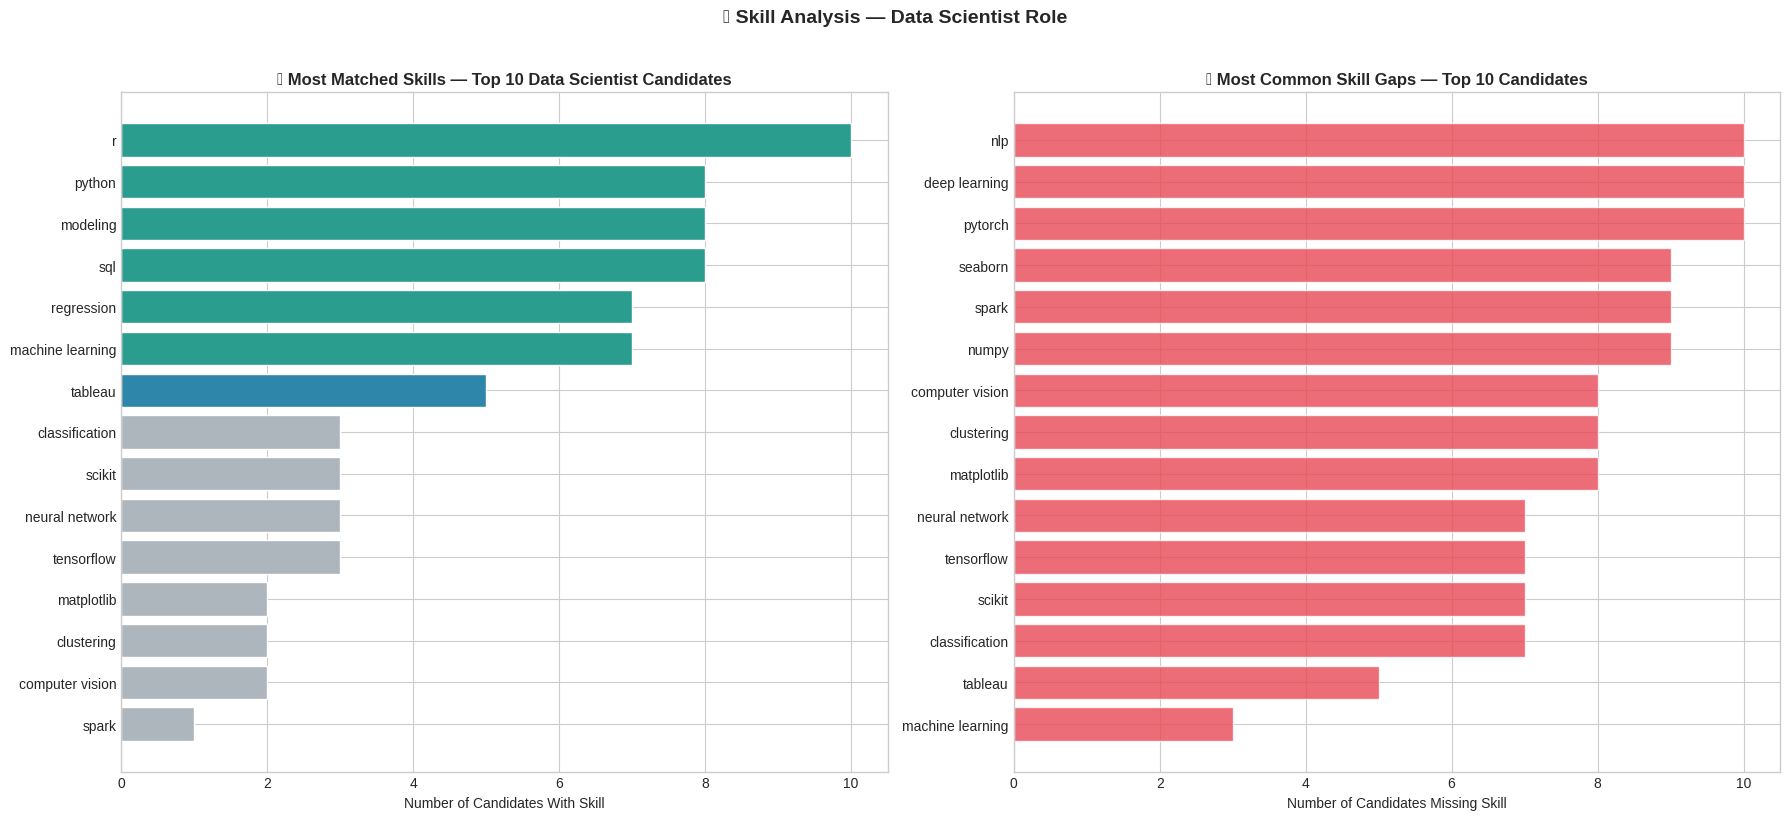

✅ Saved: skill_analysis.png


In [15]:
# ============================================================
# CELL 13: Skill Gap Analysis Charts
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ── Top matched skills — Data Scientist role ───────────────
ds_top10 = all_results['Data Scientist'].head(10)
all_matched = [s for skills in ds_top10['matched_skills']
               for s in skills]
skill_freq = Counter(all_matched).most_common(15)

skills_list = [s[0] for s in skill_freq]
freq_list   = [s[1] for s in skill_freq]
col_list    = ['#2A9D8F' if f >= 7 else '#2E86AB'
               if f >= 4 else '#ADB5BD'
               for f in freq_list]

axes[0].barh(skills_list[::-1], freq_list[::-1],
             color=col_list[::-1], edgecolor='white')
axes[0].set_title(
    '✅ Most Matched Skills — Top 10 Data Scientist Candidates',
    fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Candidates With Skill')
axes[0].set_facecolor('#FFFFFF')

# ── Most common missing skills ─────────────────────────────
all_missing = [s for skills in ds_top10['missing_skills']
               for s in skills]
missing_freq = Counter(all_missing).most_common(15)

if missing_freq:
    miss_skills = [s[0] for s in missing_freq]
    miss_counts = [s[1] for s in missing_freq]
    axes[1].barh(miss_skills[::-1], miss_counts[::-1],
                 color='#E84855', edgecolor='white',
                 alpha=0.8)
    axes[1].set_title(
        '❌ Most Common Skill Gaps — Top 10 Candidates',
        fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Number of Candidates Missing Skill')
else:
    axes[1].text(0.5, 0.5, 'No major skill gaps found!',
                 ha='center', va='center',
                 fontsize=14, color='#2A9D8F',
                 transform=axes[1].transAxes)
axes[1].set_facecolor('#FFFFFF')

plt.suptitle(
    '🔧 Skill Analysis — Data Scientist Role',
    fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('skill_analysis.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Saved: skill_analysis.png")

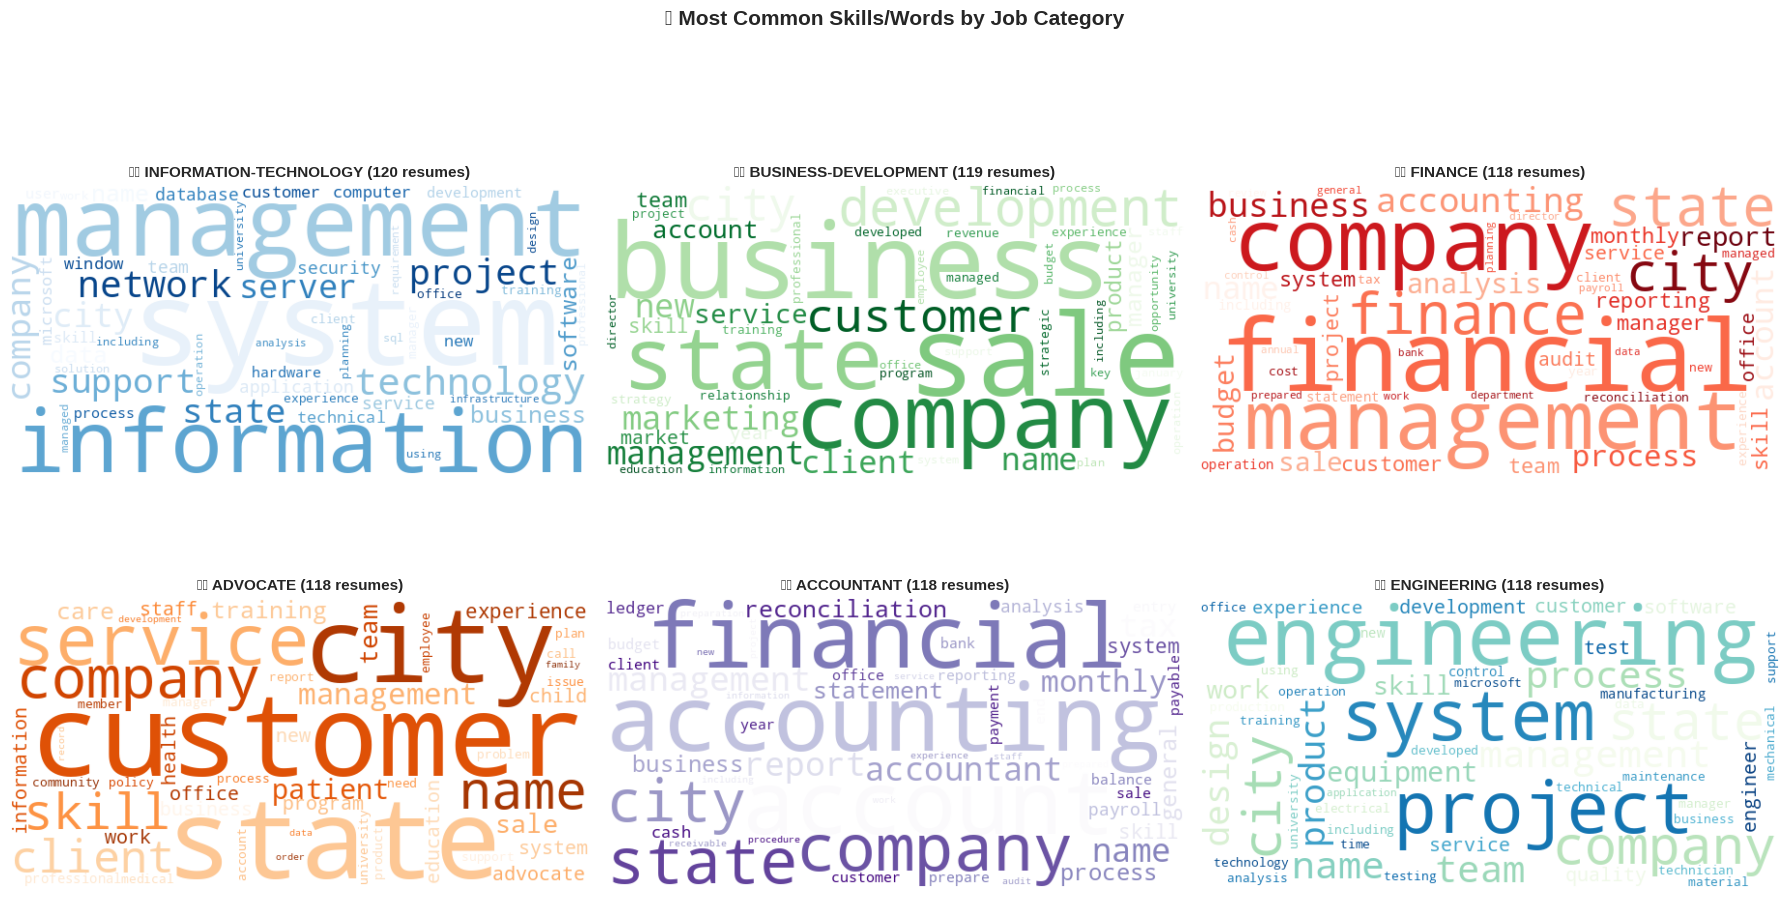

✅ Saved: word_clouds.png


In [16]:
# ============================================================
# CELL 14: Word Clouds by Job Category
# ============================================================

top_cats = df['Category'].value_counts().head(6).index.tolist()
cmaps    = ['Blues','Greens','Reds','Oranges',
            'Purples','GnBu']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, cat in enumerate(top_cats):
    text = ' '.join(
        df[df['Category']==cat]['clean_resume'].values)
    wc = WordCloud(
        width=600, height=300,
        background_color='white',
        colormap=cmaps[i],
        max_words=50,
        collocations=False
    ).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    count = len(df[df['Category']==cat])
    axes[i].set_title(
        f'☁️ {cat} ({count} resumes)',
        fontsize=11, fontweight='bold')

plt.suptitle('🔤 Most Common Skills/Words by Job Category',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('word_clouds.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Saved: word_clouds.png")

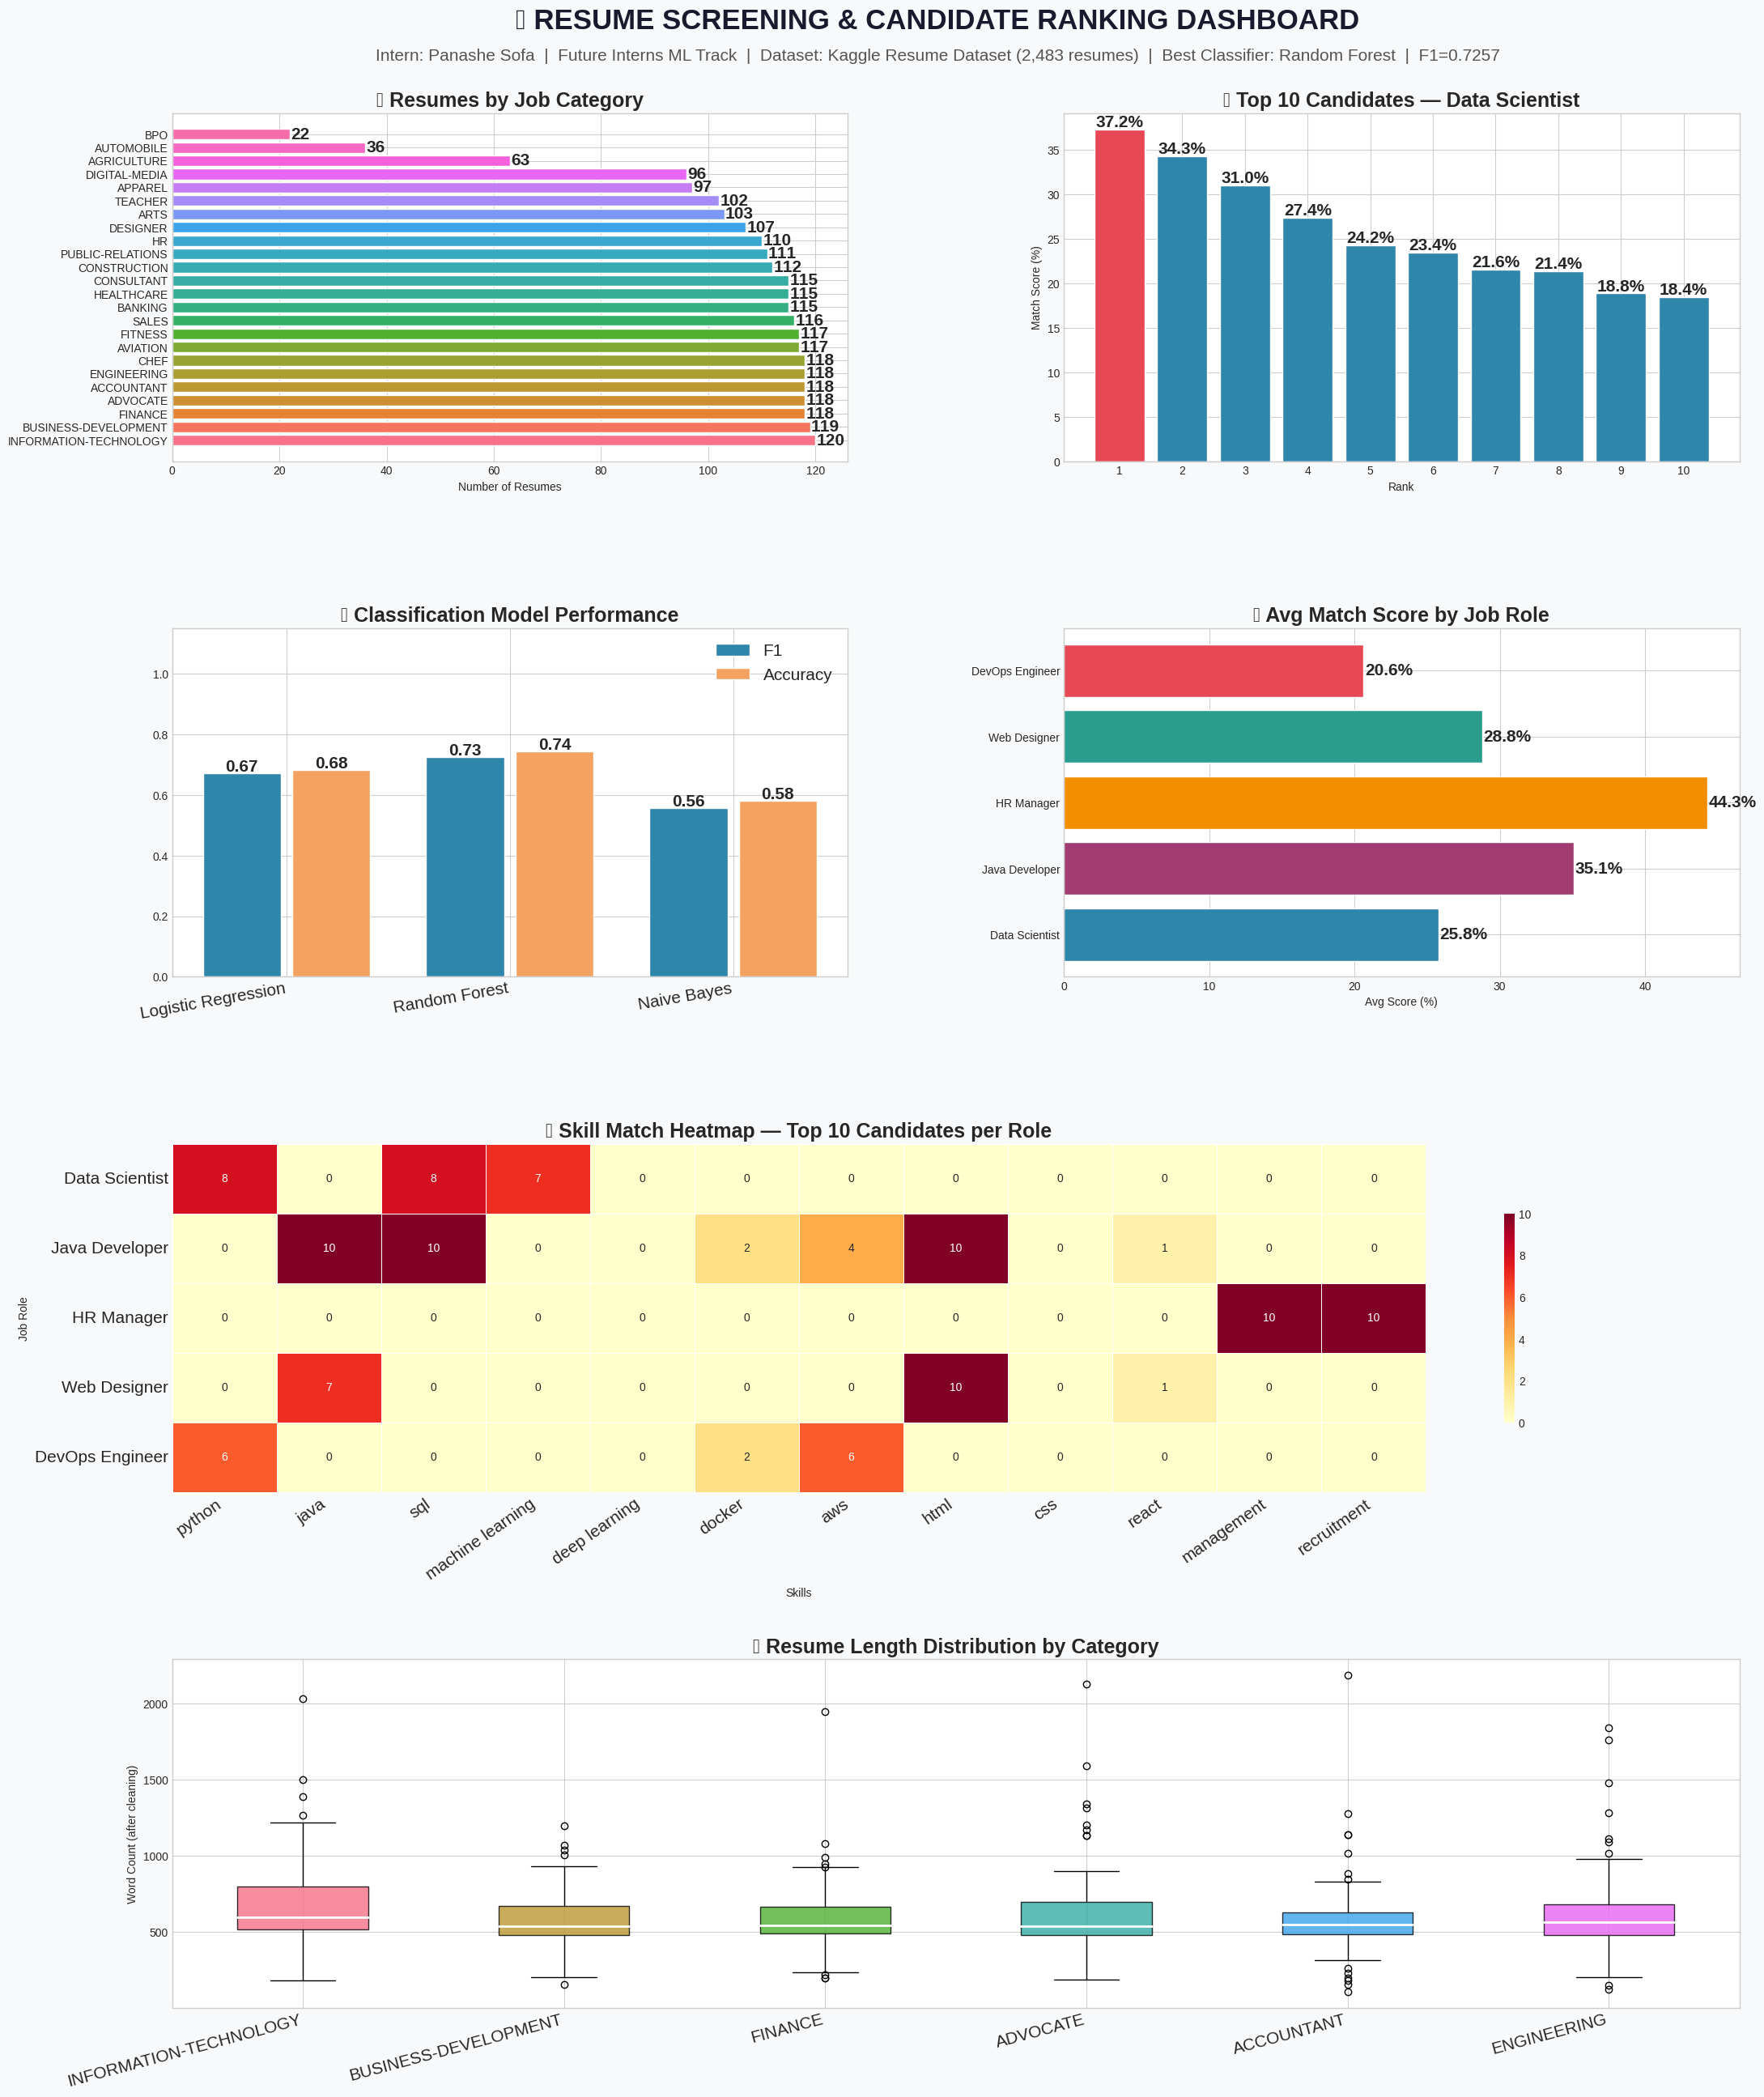

✅ SAVED: resume_dashboard.png


In [20]:
# ============================================================
# CELL 15: Full Professional Dashboard
# ============================================================

fig = plt.figure(figsize=(22, 26))
fig.patch.set_facecolor('#F8F9FA')

fig.text(0.5, 0.98,
    '📄 RESUME SCREENING & CANDIDATE RANKING DASHBOARD',
    ha='center', fontsize=25,
    fontweight='bold', color='#1A1A2E')
fig.text(0.5, 0.965,
    f'Intern: Panashe Sofa  |  Future Interns ML Track  |  '
    f'Dataset: Kaggle Resume Dataset ({len(df):,} resumes)  |  '
    f'Best Classifier: {best_clf_name}  |  '
    f'F1={clf_results[best_clf_name]["F1"]:.4f}',
    ha='center', fontsize=15, color='#555')

gs = fig.add_gridspec(
    4, 2, hspace=0.48, wspace=0.32,
    left=0.07, right=0.95,
    top=0.94, bottom=0.04)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[2, :])
ax6 = fig.add_subplot(gs[3, :])

# Panel 1: Category counts
cat_counts = df['Category'].value_counts()
colors_p   = sns.color_palette("husl", len(cat_counts))
bars = ax1.barh(cat_counts.index, cat_counts.values,
                color=colors_p, edgecolor='white')
ax1.set_title('📄 Resumes by Job Category',
              fontweight='bold', fontsize=18)
ax1.set_xlabel('Number of Resumes')
for bar in bars:
    ax1.text(bar.get_width()+0.2,
             bar.get_y()+bar.get_height()/2,
             f'{int(bar.get_width())}',
             va='center', fontsize=15,
             fontweight='bold')
ax1.set_facecolor('#FFFFFF')

# Panel 2: Data Scientist top-10 scores
ds_res    = all_results['Data Scientist']
ds_scores = ds_res['final_percent'].values
ds_cats   = ds_res['Category'].values
bar_cols  = ['#E84855' if i == 0 else '#2E86AB'
             for i in range(len(ds_scores))]
bars2 = ax2.bar(range(1, 11), ds_scores,
                color=bar_cols, edgecolor='white')
ax2.set_title(
    '🏆 Top 10 Candidates — Data Scientist',
    fontweight='bold', fontsize=18)
ax2.set_xlabel('Rank')
ax2.set_ylabel('Match Score (%)')
ax2.set_xticks(range(1, 11))
for i, (v, c) in enumerate(zip(ds_scores, ds_cats)):
    ax2.text(i+1, v+0.3, f'{v:.1f}%',
             ha='center', fontsize=15,
             fontweight='bold')
ax2.set_facecolor('#FFFFFF')

# Panel 3: Model comparison
names_m = list(clf_results.keys())
f1s  = [clf_results[n]['F1']       for n in names_m]
accs = [clf_results[n]['Accuracy'] for n in names_m]
x = np.arange(len(names_m))
b1 = ax3.bar(x-0.2, f1s,  0.35, label='F1',
             color='#2E86AB', edgecolor='white')
b2 = ax3.bar(x+0.2, accs, 0.35, label='Accuracy',
             color='#F4A261', edgecolor='white')
for bar in list(b1)+list(b2):
    ax3.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.005,
             f'{bar.get_height():.2f}',
             ha='center', fontsize=15,
             fontweight='bold')
ax3.set_title('🤖 Classification Model Performance',
              fontweight='bold', fontsize=18)
ax3.set_xticks(x)
ax3.set_xticklabels(names_m, rotation=10,
                    ha='right', fontsize=15)
ax3.set_ylim(0, 1.15)
ax3.legend(fontsize=15)
ax3.set_facecolor('#FFFFFF')

# Panel 4: Avg scores across roles
role_avgs = {
    role: all_results[role]['final_percent'].mean()
    for role in job_descriptions
}
ax4.barh(list(role_avgs.keys()),
         list(role_avgs.values()),
         color=['#2E86AB','#A23B72','#F18F01',
                '#2A9D8F','#E84855'],
         edgecolor='white')
ax4.set_title('📊 Avg Match Score by Job Role',
              fontweight='bold', fontsize=18)
ax4.set_xlabel('Avg Score (%)')
for i, (r, s) in enumerate(role_avgs.items()):
    ax4.text(s+0.1, i, f'{s:.1f}%',
             va='center', fontsize=15,
             fontweight='bold')
ax4.set_facecolor('#FFFFFF')

# Panel 5: Skill frequency heatmap across roles
skill_data = {}
key_skills = ['python','java','sql','machine learning',
              'deep learning','docker','aws','html',
              'css','react','management','recruitment']
for role in job_descriptions:
    res = all_results[role].head(10)
    all_m = [s for sl in res['matched_skills'] for s in sl]
    counts = Counter(all_m)
    skill_data[role] = [counts.get(s, 0) for s in key_skills]

hm_df = pd.DataFrame(
    skill_data, index=key_skills).T
sns.heatmap(hm_df, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            ax=ax5, cbar_kws={'shrink':0.6})
ax5.set_title(
    '🔥 Skill Match Heatmap — Top 10 Candidates per Role',
    fontweight='bold', fontsize=18)
ax5.set_xlabel('Skills')
ax5.set_ylabel('Job Role')
plt.setp(ax5.get_xticklabels(),
         rotation=35, ha='right', fontsize=15)
plt.setp(ax5.get_yticklabels(),
         rotation=0, fontsize=15)

# Panel 6: Word count distribution by category
top6 = df['Category'].value_counts().head(6).index
data_box = [df[df['Category']==c]['word_count'].values
            for c in top6]
bp = ax6.boxplot(data_box, patch_artist=True,
                 medianprops={'color':'white',
                              'linewidth':2})
palette = sns.color_palette("husl", len(top6))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax6.set_xticklabels(top6, rotation=15,
                    ha='right', fontsize=15)
ax6.set_title(
    '📏 Resume Length Distribution by Category',
    fontweight='bold', fontsize=18)
ax6.set_ylabel('Word Count (after cleaning)')
ax6.set_facecolor('#FFFFFF')

plt.savefig('resume_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("✅ SAVED: resume_dashboard.png")

---
## 📊 System Summary & Business Insights

### 🔍 How the Scoring Works
1. **TF-IDF Similarity (70%)** — measures how much the
   resume text overlaps with the job description language
2. **Skill Match Score (30%)** — counts how many required
   skills from the JD appear in the resume
3. **Combined Score** = 0.70 × TF-IDF + 0.30 × Skill Match

### 🤖 Classification Results (Category Prediction)
Used to understand what type of professional wrote each resume

| Model | Accuracy | F1 Score |
|---|---|---|
| Logistic Regression | 0.6841 | 0.6722 |
| Random Forest | 0.7445 | 0.7257 |
| Naive Bayes | 0.5815 | 0.5575 |


### 💡 How a Recruiter Uses This System

| Recruiter Need | System Output |
|---|---|
| Find best Data Science candidates | Top 10 ranked by match score |
| Understand why a candidate ranked high | Skill match count + preview |
| Identify what skills candidates lack | Skill gap list per candidate |
| Screen 2,000+ resumes instantly | Done in seconds |

### 🛠️ Technologies Used
`Python` | `NLTK` | `TF-IDF` | `Cosine Similarity` |
`Scikit-learn` | `Logistic Regression` | `Random Forest` |
`Pandas` | `Matplotlib` | `WordCloud`